In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F
from collections import deque
import random 
import pickle 

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [3]:
# tokens start from 1
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=1):
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), 1))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                self.X[ii,jj] = \
                ord(data[ii+jj])-65
      
            self.y[ii] = \
                ord(data[ii+jj+1])-65

        self.X = tnsr(self.X).long()
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [4]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, context_size, context_projection_size, use_embedding=False, embedding_dim=10):
        super().__init__()
        self.use_embedding = use_embedding

        self.context_layer = nn.Linear(context_size, context_projection_size)
        if self.use_embedding:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            self.rnn = nn.RNN(embedding_dim+context_projection_size, hidden_size, batch_first=True, nonlinearity='tanh')
        else:
            self.rnn = nn.RNN(vocab_size+context_projection_size, hidden_size, batch_first=True, nonlinearity='tanh')
        
        self.linear = nn.Linear(hidden_size, vocab_size)

        ### use orthogonal initialization of weights ### 
        for name, param in self.rnn.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
    
    def forward(self, x, context, h=None):
        context_out = self.context_layer(context)
        if self.use_embedding:
            embedded = self.embedding(x)
            # print(embedded.size(), context_out.size())
            context_expanded = context_out.unsqueeze(1).expand(-1, embedded.size(1), -1)
            embedded = torch.cat((embedded, context_expanded), dim=2)
            out, h = self.rnn(embedded, h)
        else:
            context_expanded = context_out.unsqueeze(1).expand(-1, x.size(1), -1)
            x = torch.cat((x, context_expanded), dim=2)
            out, h = self.rnn(x, h)

        out = self.linear(out[:,-1,:])

        return out, h  
    
class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, use_embedding=False, embedding_dim=10):
        super().__init__()
        self.use_embedding = use_embedding

        if self.use_embedding:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, nonlinearity='tanh')
        else:
            self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True, nonlinearity='tanh')

        self.fc = nn.Linear(hidden_size, vocab_size)

        ### use orthogonal initialization of weights ###
        for name, param in self.rnn.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
    
    def forward(self, x, h):
        if self.use_embedding:
            embedded = self.embedding(x)
            out, _ = self.rnn(embedded, h)
        else:
            out, _ = self.rnn(x, h)

        return self.fc(out) 
    
class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, context_size, context_projection_size, use_embedding=False, embedding_dim=10 ):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, hidden_size, context_size, context_projection_size, use_embedding, embedding_dim)
        self.decoder = RNNDecoder(vocab_size, hidden_size, use_embedding, embedding_dim)
    
    def forward(self, x, decoder_input, context, h=None):
        next_token, h = self.encoder(x, context, h)
        decoder_output = self.decoder(decoder_input, h)
        return next_token, decoder_output, h

In [5]:
def path_finder_loss(y_pred, decoder_output, y_target, decoder_target):
    ce1 = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_target.view(-1))
    ce2 = F.cross_entropy(decoder_output.view(-1, decoder_output.size(-1)), decoder_target.view(-1))

    return (ce1+ce2)/2

In [6]:
def path_finder_loss_mse(y_pred, decoder_output, y_target, decoder_target):
    ce1 = F.mse_loss(y_pred.view(-1), y_target.view(-1))
    ce2 = F.mse_loss(decoder_output.view(-1), decoder_target.view(-1))

    return (ce1+ce2)/2

In [7]:
def train_layer(model, optimizer, criterion, X, y, context, h=None, layer=0):
    if layer == 0:
        decoder_input = torch.cat([torch.zeros((1, 1), dtype=torch.long), X[:, :-1]], dim=1)
    else:
        decoder_input = torch.cat([torch.zeros((1, 1, X.shape[2]), dtype=torch.long), X[:, :-1]], dim=1)

    decoder_target = X.flip(1)

    optimizer.zero_grad()
    y_pred, decoder_output, h = model(X, decoder_input, context, h)
    # print(y_pred[0], 'y_pred', y[0], 'y', decoder_output[0], decoder_target[0])
    loss = criterion(y_pred[0], decoder_output[0], y[0], decoder_target[0])     
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if layer == 0:
        with torch.no_grad():
            if y[0] == y_pred[0].argmax():
                correct = 1
            else:
                correct = 0
        
        return correct, h.detach()
    
    return h.detach()
        

In [18]:
reps = 10
res = []

for rep in range(reps):
    print('Doing rep ', rep)

    total_samples = 50000
    short_term_memory = 3
    n_member = 3
    n_community = 2

    total_layers = 3
    model = {}
    input_buffer = {}
    target_buffer = {}
    context = {}
    vocab_size = n_member*n_community+1
    embedding_dim = 10
    context_projection_size = 10
    downsample_factor = short_term_memory
    lr = [1e-3,1e-3,1e-3]
    hidden_size = [50, 100, 200, 300]
    optimizers = []
    criteria = []

    for layer in range(total_layers):  
        if layer == 0:
            model[layer] = RNNAutoencoder(vocab_size, hidden_size[layer], hidden_size[layer+1], context_projection_size, use_embedding=True, embedding_dim=embedding_dim)
            criteria.append(
                path_finder_loss
            )
        else:
            model[layer] = RNNAutoencoder(hidden_size[layer-1], hidden_size[layer], hidden_size[layer+1], context_projection_size)
            input_buffer[layer] = deque(
                [torch.zeros((hidden_size[layer-1])) for _ in range(short_term_memory)],
                maxlen=short_term_memory
            )
            target_buffer[layer] = torch.zeros((hidden_size[layer-1]))
            criteria.append(
                path_finder_loss_mse
            )

        optimizers.append(
            torch.optim.Adam(model[layer].parameters(), lr=lr[layer], weight_decay=1e-8)
        )
        context[layer] = torch.zeros((1,hidden_size[layer+1]))



    ### handle data ###
    data = get_sequence(total_samples, n_community, n_member, train_percent=1.0)
    data_set = Dataset_converter(data, 1, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    ### train the model ###
    correct = np.zeros(1000,dtype=float)
    decoder_correct = np.zeros(1000,dtype=float)
    test_acc = []
    test_acc_decoder = []

    total = 0
    total_layer1 = 0
    h = None
    h1 = None
    h2 = None

    for X, y in train_loader:
        accurate, h = train_layer(model[0], optimizers[0], criteria[0], X, y, context[0], h)

        correct[total%1000] = accurate

        if total%downsample_factor==0:
            input_buffer[1].append(
                target_buffer[1].clone()
            )
            target_buffer[1] = h[0][0]

            h1 = train_layer(
                model[1], optimizers[1], criteria[1], torch.stack(list(input_buffer[1])).unsqueeze(0), 
                torch.stack(list(target_buffer[1])).unsqueeze(0), context[1], h1, layer=1
            )
            context[0][0] = h1[0][0]

            total_layer1 += 1
            if total_layer1%downsample_factor==0:
                input_buffer[2].append(
                    target_buffer[2].clone()
                )
                target_buffer[2] = h1[0][0]

                h2 = train_layer(
                    model[2], optimizers[2], criteria[2], torch.stack(list(input_buffer[2])).unsqueeze(0), 
                    torch.stack(list(target_buffer[2])).unsqueeze(0), context[2], h2, layer=1
                )
                context[1][0] = h2[0][0]

            
            
        total += 1
        
        test_acc.append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            
        if total%1000 == 0:
            print(f'Iter : {total+1}, accuracy: {test_acc[-1]:.4f}')

    res.append(
        test_acc
    )


Doing rep  0
Iter : 1001, accuracy: 0.5150
Iter : 2001, accuracy: 0.6760
Iter : 3001, accuracy: 0.6420
Iter : 4001, accuracy: 0.6690
Iter : 5001, accuracy: 0.6590
Iter : 6001, accuracy: 0.6690
Iter : 7001, accuracy: 0.6700
Iter : 8001, accuracy: 0.6470
Iter : 9001, accuracy: 0.6820
Iter : 10001, accuracy: 0.6940
Iter : 11001, accuracy: 0.6680
Iter : 12001, accuracy: 0.6730
Iter : 13001, accuracy: 0.7120
Iter : 14001, accuracy: 0.7330
Iter : 15001, accuracy: 0.7530
Iter : 16001, accuracy: 0.7760
Iter : 17001, accuracy: 0.7830
Iter : 18001, accuracy: 0.7900
Iter : 19001, accuracy: 0.7980
Iter : 20001, accuracy: 0.8020
Iter : 21001, accuracy: 0.7970
Iter : 22001, accuracy: 0.7920
Iter : 23001, accuracy: 0.7980
Iter : 24001, accuracy: 0.7880
Iter : 25001, accuracy: 0.7790
Iter : 26001, accuracy: 0.8000
Iter : 27001, accuracy: 0.7950
Iter : 28001, accuracy: 0.7890
Iter : 29001, accuracy: 0.7890
Iter : 30001, accuracy: 0.7830
Iter : 31001, accuracy: 0.7910
Iter : 32001, accuracy: 0.7840
Iter

In [19]:
with open('../pickle_files/model_downsampling_hidden_state_layer3.pickle', 'wb') as f:
    pickle.dump(res, f)

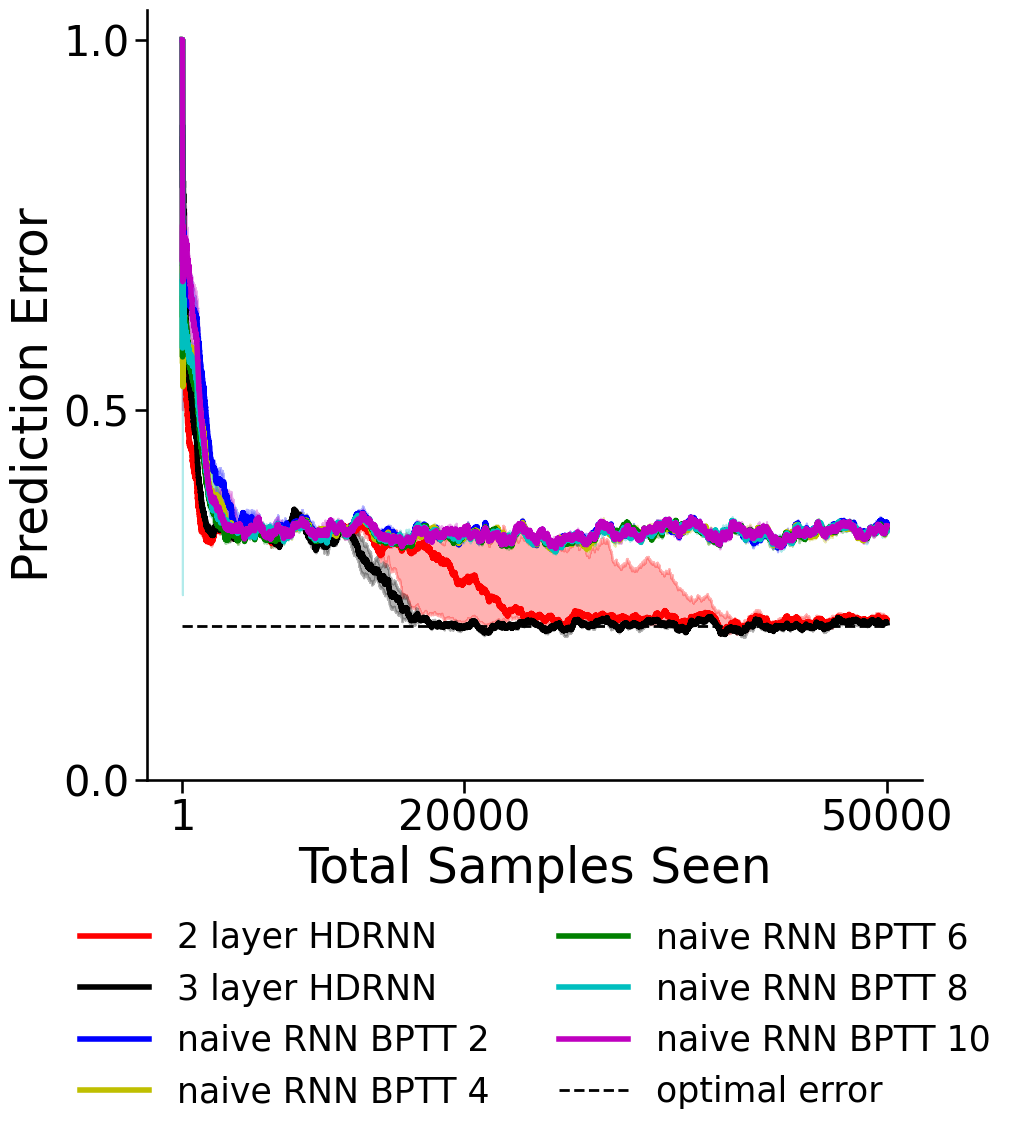

In [24]:
with open('../pickle_files/model_downsampling_hidden_state.pickle', 'rb') as f:
    res_hier = 1 - np.array(pickle.load(f))

with open('../pickle_files/model_downsampling_hidden_state_layer3.pickle', 'rb') as f:
    res_hier3 = 1 - np.array(pickle.load(f))

clr = ['b', 'y', 'g', 'c', 'm']
short_term_memories = [2,4,6,8,10]
with open('../pickle_files/naive_rnn.pickle', 'rb') as f:
    res_naive = pickle.load(f)

fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharey=True, sharex=True)
sns.set_context('talk')
fontsize=40

ax.plot(np.arange(1,49997), np.median(res_hier, axis=0), color='r', label='2 layer HDRNN', linewidth=4)
ax.fill_between(np.arange(1,49997), np.quantile(res_hier, [0.25], axis=0)[0], np.quantile(res_hier, [0.75], axis=0)[0], color='r', alpha=.3)

ax.plot(np.arange(1,49997), np.median(res_hier3, axis=0), color='k', label='3 layer HDRNN', linewidth=4)
ax.fill_between(np.arange(1,49997), np.quantile(res_hier3, [0.25], axis=0)[0], np.quantile(res_hier3, [0.75], axis=0)[0], color='k', alpha=.3)

for ii, short_term_memory in enumerate(short_term_memories):
    res = 1 - np.array(res_naive[short_term_memory])

    ax.plot(np.arange(1,res.shape[1]+1), np.median(res, axis=0), label='naive RNN BPTT '+str(short_term_memory), linewidth=4, color=clr[ii])
    ax.fill_between(np.arange(1,res.shape[1]+1), np.quantile(res, [0.25], axis=0)[0], np.quantile(res, [0.75], axis=0)[0], alpha=.3, color=clr[ii])


ax.hlines(1-0.7917, 1, 50000, linestyle='--', color='black', linewidth=2, label='optimal error')

ax.set_yticks([0,.5,1])
ax.set_xticks([1,20000,50000])
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

ax.tick_params(labelsize=fontsize-10)
ax.set_xlabel('Total Samples Seen', fontsize=fontsize-5)
ax.set_ylabel('Prediction Error', fontsize=fontsize-5)

leg = fig.legend(bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure,
                        ncol=2, fontsize=25, frameon=False)

plt.savefig('../plots/HDRNN_sim.pdf', bbox_inches='tight')